<a href="https://colab.research.google.com/github/rdsmaia/dim0494/blob/main/autoencoder_mnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
import numpy as np
from matplotlib import pyplot as plt
from tensorflow import keras
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Flatten, Reshape
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split

In [21]:
# Load MNIST data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [22]:
# Normalize data: pixels between 0-1
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

In [23]:
# flatten images: from 2D to 1D
_, width, height = x_train.shape
x_train = x_train.reshape((len(x_train), width * height))
x_test = x_test.reshape((len(x_test), width * height))
print(x_train.shape)
print(x_test.shape)

(60000, 784)
(10000, 784)


In [24]:
# create a validation set: take data from the train set
x_train, x_val, y_train, y_val = train_test_split(x_train,
                                                  y_train,
                                                  test_size=0.2,
                                                  random_state=42,
                                                  stratify=y_train)

In [25]:
# Define dimensions: input and latent
input_dim = x_train.shape[1]
latent_dim = 64  # You can try 32, 128, etc.

In [26]:
# Model

# Encoder
encoder = keras.Sequential(
    [
        Input(shape=(input_dim,)),
        Dense(256, activation='relu'),
        Dense(128, activation='relu'),
        Dense(latent_dim, activation='relu')
    ])

# Decoder
decoder = keras.Sequential(
    [
        Input(shape=(latent_dim,)),
        Dense(128, activation='relu'),
        Dense(256, activation='relu'),
        Dense(input_dim, activation='linear')
  ])

# Autoencoder model: encoder and decoder in sequence
autoencoder = keras.Sequential([encoder, decoder])

autoencoder.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)       │ (None, 64)             │       242,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_4 (Sequential)       │ (None, 784)            │       242,832 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 484,944 (1.85 MB)

 Trainable params: 484,944 (1.85 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
# hyperparameters
batch_size = 256
epochs = 20
learning_rate = 0.001
beta1 = 0.9
beta2 = 0.999
epsilon = 1e-8
loss = 'mse'

In [28]:
# Compile model
autoencoder.compile(
    optimizer=Adam(
    learning_rate=learning_rate,
    beta_1=beta1,
    beta_2=beta2,
    epsilon=epsilon),
    loss='mse')

In [29]:
# Train model
history = autoencoder.fit(x_train, x_train,
                          epochs=epochs,
                          batch_size=batch_size,
                          shuffle=True,
                          validation_data=(x_val, x_val)
                          )

Epoch 1/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.0581 - val_loss: 0.0240
Epoch 2/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0223 - val_loss: 0.0187
Epoch 3/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0182 - val_loss: 0.0166
Epoch 4/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0164 - val_loss: 0.0155
Epoch 5/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0153 - val_loss: 0.0148
Epoch 6/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0146 - val_loss: 0.0142
Epoch 7/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0141 - val_loss: 0.0137
Epoch 8/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0137 - val_loss: 0.0133
Epoch 9/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0133 - val_loss: 0.0130
Epoch 10/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0129 - val_loss: 0.0129
Epoch 11/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0128 - val_loss: 0.0130
Epoch 12/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/ste

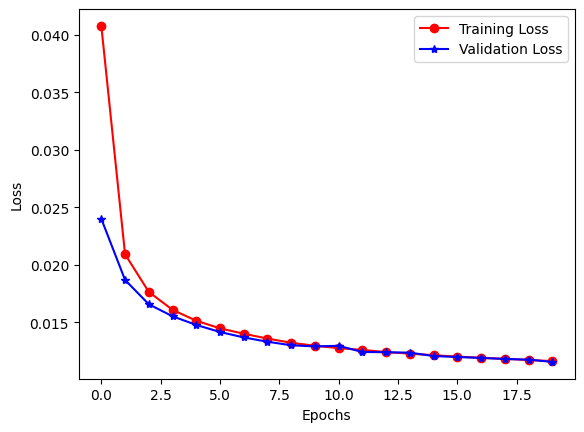

In [30]:
# observe the learning curves
plt.plot(history.history['loss'], 'r-o', label='Training Loss')
plt.plot(history.history['val_loss'], 'b-*', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


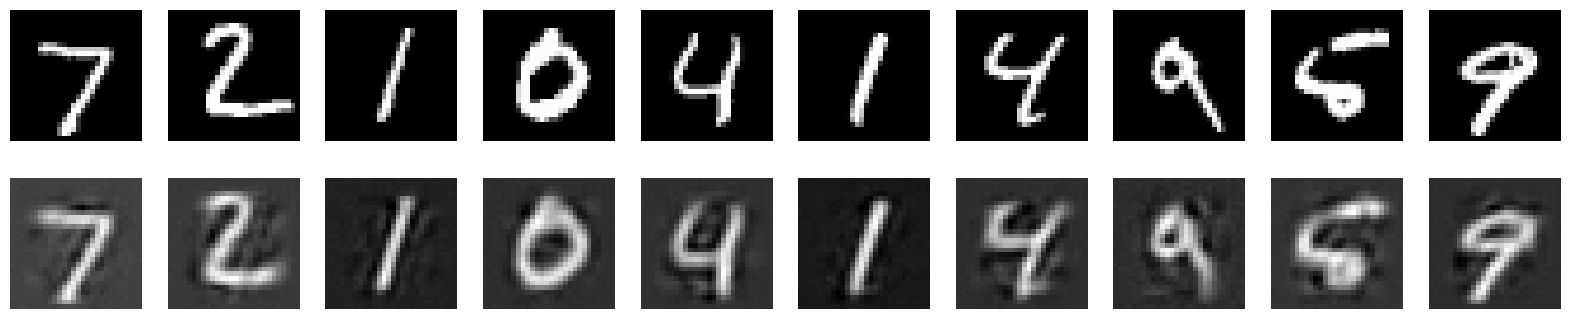

In [31]:
# Testing the model

# from images to latents
latents = encoder.predict(x_test)

# from latents to reconstructed images
x_test_hat = decoder.predict(latents)

# Plot original and reconstructed
n = 10  # How many digits to display
plt.figure(figsize=(20, 4))
for i in range(n):

    # Original image
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.axis('off')

    # Reconstructed image
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(x_test_hat[i].reshape(28, 28), cmap='gray')
    plt.axis('off')

plt.show()


In [32]:
# observing the latent space: just the first 2 dimensions: we will use t-SNE
from sklearn.manifold import TSNE
latents_2D = TSNE(n_components=2).fit_transform(latents)

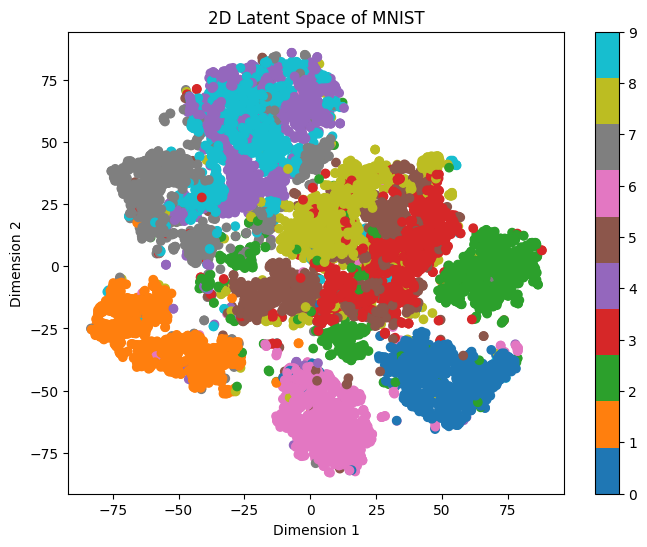

In [33]:
# plotting the 2D latents with corresponding labels
plt.figure(figsize=(8, 6))
plt.scatter(latents_2D[:, 0], latents_2D[:, 1], c=y_test, cmap='tab10')  # use true labels if available
plt.colorbar()
plt.title("2D Latent Space of MNIST")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.show()